In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, classification_report, make_scorer,
    RocCurveDisplay, ConfusionMatrixDisplay
)
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
import joblib



In [4]:
def symulacja_budzetu(y_true, y_proba, budzet=200, koszt_reklamy=10):
    max_reklam = budzet // koszt_reklamy

    wyniki = pd.DataFrame({'y_true': y_true, 'proba': y_proba})
    wyniki_posortowane = wyniki.sort_values(by='proba', ascending=False)

    wybrane = wyniki_posortowane.head(max_reklam)

    tp = (wybrane['y_true'] == 1).sum()
    fp = (wybrane['y_true'] == 0).sum()

    oczekiwana_liczba_adopcji = (tp * 0.70) + (fp * 0.10)

    return oczekiwana_liczba_adopcji

In [5]:
from sklearn.metrics import make_scorer

def moja_metryka(y_true, y_proba, **kwargs):
    return symulacja_budzetu(y_true, y_proba)

scorer = make_scorer(moja_metryka, needs_proba=True)

In [2]:
df = pd.read_csv('/content/pet_adoption_data.csv')

X = df.drop('AdoptionLikelihood', axis=1)
y = df['AdoptionLikelihood'].values.ravel()
X.drop('PetID', axis=1, inplace=True)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

zmienne_kategoryczne = ['PetType', 'Breed', 'Color', 'Size']
zmienne_numeryczne = [col for col in X.columns if col not in zmienne_kategoryczne]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), zmienne_numeryczne),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), zmienne_kategoryczne)
    ])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(score_func=f_classif)),
    ('log_reg', LogisticRegression(max_iter=5000, random_state=42))
])



In [6]:

pipeline.fit(X_train, y_train)
y_pred_base = pipeline.predict(X_test)
y_proba_base = pipeline.predict_proba(X_test)[:, 1]

print('Wyniki modelu bazowego:')
print(classification_report(y_test, y_pred_base))
print('Accuracy:', accuracy_score(y_test, y_pred_base))

# RocCurveDisplay.from_estimator(log_reg, X_test, y_test)
# plt.show()

# cm = confusion_matrix(y_test, y_pred_base)
# ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
# plt.title('Macierz pomyłek modelu bazowego')
# plt.show()

baseline_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_base),
    "recall": recall_score(y_test, y_pred_base),
    "precision": precision_score(y_test, y_pred_base),
    "f1": f1_score(y_test, y_pred_base),
    "auc": roc_auc_score(y_test, y_proba_base)
}


Wyniki modelu bazowego:
              precision    recall  f1-score   support

           0       0.86      0.97      0.91       270
           1       0.91      0.69      0.78       132

    accuracy                           0.88       402
   macro avg       0.89      0.83      0.85       402
weighted avg       0.88      0.88      0.87       402

Accuracy: 0.8756218905472637


## Badanie wpływu hiperparametrów

In [7]:
param_grid = [
    {
        "feature_selection__k": [5, 10, 15, 'all'],
        "log_reg__C": np.logspace(-4, 4, 9),
        "log_reg__penalty": ["l2"],
        "log_reg__solver": ["lbfgs", "liblinear", "saga"]
    },
    {
        "feature_selection__k": [5, 10, 15, 'all'],
        "log_reg__C": np.logspace(-4, 4, 9),
        "log_reg__penalty": ["l1"],
        "log_reg__solver": ["liblinear", "saga"]
    }
]

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring={
        "recall": "recall",
        "precision": "precision",
        "auc": "roc_auc",
        "biznesowa": scorer
    },
    refit="biznesowa",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Najlepsze hiperparametry:", grid.best_params_)
print("Najlepsza oczekiwana liczba adopcji w CV:", grid.best_score_)

best_model = grid.best_estimator_
y_pred_tuned = best_model.predict(X_test)
y_proba_tuned = best_model.predict_proba(X_test)[:, 1]

tuned_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_tuned),
    "recall": recall_score(y_test, y_pred_tuned),
    "precision": precision_score(y_test, y_pred_tuned),
    "f1": f1_score(y_test, y_pred_tuned),
    "auc": roc_auc_score(y_test, y_proba_tuned)
}



Fitting 5 folds for each of 180 candidates, totalling 900 fits
Najlepsze hiperparametry: {'feature_selection__k': 5, 'log_reg__C': np.float64(0.01), 'log_reg__penalty': 'l2', 'log_reg__solver': 'lbfgs'}
Najlepsza oczekiwana liczba adopcji w CV: 13.52


In [12]:
#sprawdzenie 5 znalezionych, najlepszych cech
preprocesor = best_model.named_steps['preprocessor']
selektor = best_model.named_steps['feature_selection']

wszystkie_cechy = preprocesor.get_feature_names_out()

wybrane_maska = selektor.get_support()

wybrane_cechy = wszystkie_cechy[wybrane_maska]

print("5 najważniejszych cech decydujących o adopcji (wg SelectKBest):")
for i, cecha in enumerate(wybrane_cechy, 1):
    czysta_nazwa = cecha.replace('num__', '').replace('cat__', '')
    print(f"{i}. {czysta_nazwa}")

5 najważniejszych cech decydujących o adopcji (wg SelectKBest):
1. Vaccinated
2. HealthCondition
3. Breed_Labrador
4. Size_Medium
5. Size_Small


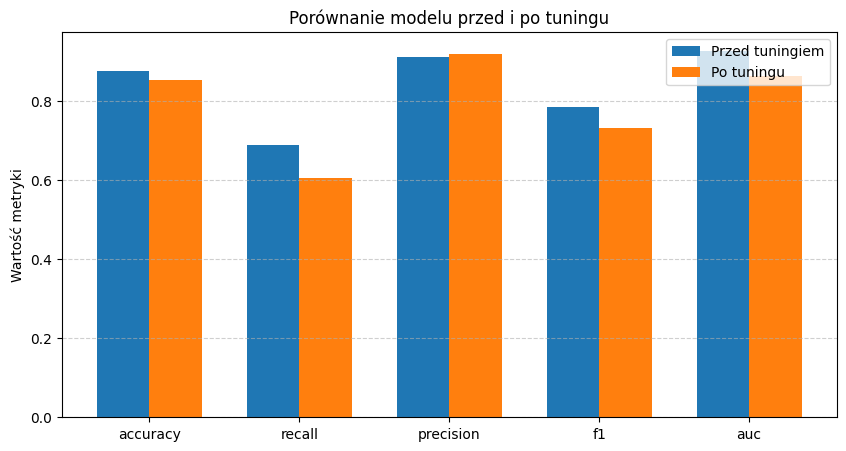

In [8]:
#porównanie metryk

labels = list(baseline_metrics.keys())
baseline_vals = list(baseline_metrics.values())
tuned_vals = list(tuned_metrics.values())

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, baseline_vals, width, label="Przed tuningiem")
plt.bar(x + width/2, tuned_vals, width, label="Po tuningu")
plt.xticks(x, labels)
plt.ylabel("Wartość metryki")
plt.title("Porównanie modelu przed i po tuningu")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

wykresy potwierdzają dopasowanie się modelu do metryki biznesowej, a nie standardowych miar jakości. Interesuje nas tylko precision (jak największa ilość TP)

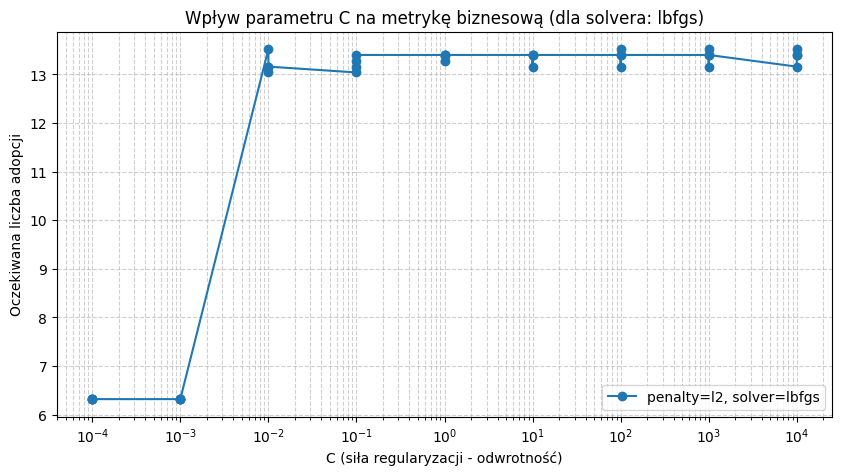

In [9]:
#wpływ parametru C

results = grid.cv_results_
best_solver = grid.best_params_["log_reg__solver"]

plt.figure(figsize=(10, 5))

for penalty in ["l1", "l2"]:
    mask = np.array([
        (p == penalty) and (s == best_solver)
        for p, s in zip(results["param_log_reg__penalty"], results["param_log_reg__solver"])
    ])

    if not mask.any():
        continue

    Cs = np.array(results["param_log_reg__C"])[mask].astype(float)
    biznesowa_score = np.array(results["mean_test_biznesowa"])[mask]

    sort_idx = np.argsort(Cs)
    plt.semilogx(Cs[sort_idx], biznesowa_score[sort_idx], marker="o", label=f"penalty={penalty}, solver={best_solver}")

plt.xlabel("C (siła regularyzacji - odwrotność)")
plt.ylabel("Oczekiwana liczba adopcji")
plt.title(f"Wpływ parametru C na metrykę biznesową (dla solvera: {best_solver})")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.show()



WYNIKI SYMULACJI BIZNESOWEJ NA ZBIORZE TESTOWYM
Oczekiwana liczba adopcji (model bazowy):     13.40
Oczekiwana liczba adopcji (model po tuningu): 14.00


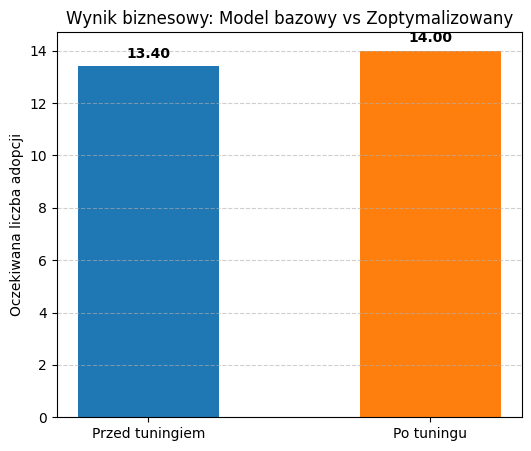

['model_logreg.pkl']

In [14]:
# Symulacja na zbiorze testowym dla modelu (baseline) na domyślnych parametrach

base_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('log_reg', LogisticRegression(max_iter=5000, random_state=42))
])
base_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('log_reg', LogisticRegression(max_iter=5000, random_state=42))
])
base_pipeline.fit(X_train, y_train)

y_proba_base = base_pipeline.predict_proba(X_test)[:, 1]
y_proba_tuned = best_model.predict_proba(X_test)[:, 1]

oczekiwane_adopcje_base = symulacja_budzetu(y_test, y_proba_base)
oczekiwane_adopcje_tuned = symulacja_budzetu(y_test, y_proba_tuned)

print("\nWYNIKI SYMULACJI BIZNESOWEJ NA ZBIORZE TESTOWYM")
print(f"Oczekiwana liczba adopcji (model bazowy):     {oczekiwane_adopcje_base:.2f}")
print(f"Oczekiwana liczba adopcji (model po tuningu): {oczekiwane_adopcje_tuned:.2f}")

# Wykres biznesowy
plt.figure(figsize=(6, 5))
plt.bar(["Przed tuningiem", "Po tuningu"],
        [oczekiwane_adopcje_base, oczekiwane_adopcje_tuned],
        color=['#1f77b4', '#ff7f0e'], width=0.5)
plt.ylabel("Oczekiwana liczba adopcji")
plt.title("Wynik biznesowy: Model bazowy vs Zoptymalizowany")
plt.grid(axis="y", linestyle="--", alpha=0.6)
for i, v in enumerate([oczekiwane_adopcje_base, oczekiwane_adopcje_tuned]):
    plt.text(i, v + 0.2, f"{v:.2f}", ha='center', va='bottom', fontweight='bold')
plt.show()



joblib.dump(best_model, 'model_logreg.pkl')